# Iteration 0: Baseline Binary Classification — RQ1

**Research Questions:** RQ1 (Process-safety classification)

**Objective:** Establish a reproducible baseline for binary classification of incident reports into *Process Safety* vs. *Non-Process Safety* using BERT-base-uncased embeddings with a Support Vector Machine (SVM). This iteration performs end-to-end data preparation — loading, schema alignment, deduplication, cleaning, language detection, and exploratory data analysis (EDA) — followed by embedding generation, model training, and evaluation on three English-language dataset variants.

**Outputs:** Master dataset (`master_df.json`), per-country and per-language JSON splits, BERT `[CLS]` embeddings (`.npy`), trained SVM models (`.joblib`), classification reports, confusion matrices, EDA visualisations, and `iteration_0_summary.json`.

---

## 1. Configuration and Data Loading
This section initialises the environment for reproducible analysis. Cross-platform path resolution ensures portability across operating systems, output directories are created automatically, and four source datasets (JSONL format) are loaded into pandas DataFrames. These datasets represent different data snapshots and sources, forming the foundation for all subsequent processing.

In [1]:
# -----------------------------
# Configuration & Path Setups
# -----------------------------

import pandas as pd
import numpy as np
import os
from pathlib import Path
from typing import Union, Optional
import plotly.graph_objects as go
import plotly.io as pio
from concurrent.futures import ProcessPoolExecutor

pio.kaleido.scope.mathjax = None

def find_project_root_with_datasets(start_path: Path, max_levels: int = 10) -> Path:
    """
    Search upward from start_path for a directory containing 'Datasets' folder.
    This makes the notebook work on any system (macOS, Windows, Linux).
    """
    cur = start_path.resolve()
    for _ in range(max_levels):
        if (cur / 'Datasets').exists():
            return cur
        cur = cur.parent
    raise FileNotFoundError(
        f"Could not find project root with 'Datasets' folder within {max_levels} levels. "
        f"Set THESIS_BASE_DIR environment variable or ensure Datasets folder exists."
    )


env_base = os.environ.get('THESIS_BASE_DIR')
if env_base:
    BASE_DIR = Path(env_base)
    print(f"Using THESIS_BASE_DIR from environment: {BASE_DIR}")
else:
    BASE_DIR = find_project_root_with_datasets(Path.cwd())
    print(f"Found project root: {BASE_DIR}")

PATHS = {
    'raw_data': BASE_DIR / "Datasets" / "RW_Datasets",
    'embeddings': BASE_DIR / "Embeddings" / "_iteration_0" / "bert-base-uncased",
    'results': BASE_DIR / "Results" / "_iteration_0"
}


for k, p in list(PATHS.items()):
    PATHS[k] = Path(p).resolve()


for path in PATHS.values():
    path.mkdir(parents=True, exist_ok=True)

DATA_FILES = {
    'df_14': PATHS['raw_data'] / "14K_Reports_RW_ACTUALS_PS.jsonl",
    'df_28': PATHS['raw_data'] / "28k_Reports_RW_ACTUALS_ALL.jsonl",
    'df_30': PATHS['raw_data'] / "30K_Reports_RW_ACTUALS_ALL_v2.0.jsonl",
    'df_700': PATHS['raw_data'] / "700k_reports_RW_ACTUALS_NH_OBS.jsonl"
}

def load_data(file_path: Union[str, Path]) -> Optional[pd.DataFrame]:
    """
    Load a JSONL file into a DataFrame with error handling.
    
    Parameters: 
        file_path (Union[str, Path]): Path to the JSONL data file
        
    Returns:
        pandas.DataFrame: Loaded data or None if file not found
    """
    file_path = Path(file_path)
    try:
        df = pd.read_json(file_path, lines=True)
        print(f"Successfully loaded {file_path.name} ({len(df)} rows)")
        return df
    except Exception as e:
        print(f"An error occurred while loading {file_path.name}: {e}")
        return None

# Load Each File (JSONL files)
RW_ACTUALS_PS_14 = load_data(DATA_FILES['df_14'])
RW_ACTUALS_ALL_28 = load_data(DATA_FILES['df_28'])
RW_ACTUALS_ALL_30 = load_data(DATA_FILES['df_30'])
RW_ACTUALS_NH_OBS_700 = load_data(DATA_FILES['df_700'])

# Check if all dataframes were loaded successfully
if all(df is not None for df in [RW_ACTUALS_PS_14, RW_ACTUALS_ALL_28, RW_ACTUALS_ALL_30, RW_ACTUALS_NH_OBS_700]):
    print("\n[OK] All files loaded successfully!")
else:
    print("\n[WARNING] Some files failed to load. Please check the file paths and try again.")

Found project root: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
Successfully loaded 14K_Reports_RW_ACTUALS_PS.jsonl (14432 rows)
Successfully loaded 28k_Reports_RW_ACTUALS_ALL.jsonl (28323 rows)
Successfully loaded 30K_Reports_RW_ACTUALS_ALL_v2.0.jsonl (30609 rows)
Successfully loaded 700k_reports_RW_ACTUALS_NH_OBS.jsonl (717041 rows)

[OK] All files loaded successfully!


## 2. Schema Alignment
All four source datasets are aligned to a unified schema prior to merging. Column renaming ensures consistency (e.g., `DATETIME` → `CASE_OCCURENCE_DATE` in the 700K dataset), missing columns are added where absent (e.g., `IMM_ACTION_TAKEN_RECOM` in the 30K dataset), and extraneous columns are dropped. This harmonisation guarantees that all datasets share an identical structure for concatenation.

In [2]:
# =============================================================================
# Adjust datasets according to the column mapping comments
# =============================================================================

# --- 700K Dataset Fixes ---
# Rename DATETIME → CASE_OCCURENCE_DATE (comment: "Rename in 700k Reports")
rename_map_700k = {
    "DATETIME": "CASE_OCCURENCE_DATE",
}
RW_ACTUALS_NH_OBS_700 = RW_ACTUALS_NH_OBS_700.rename(
    columns={k: v for k, v in rename_map_700k.items() if k in RW_ACTUALS_NH_OBS_700.columns}
)

# --- 30K Dataset Fixes ---
# 1) Rename columns (comment: "Rename in 30k Reports")
rename_map_30k = {
    "EMPLOYMENT_CATEGORY": "COMPANY_INVOLVED_TYPE",
    "HAZARD_PHYSICAL_SECURITY_EVENT": "HAZARD",
}
RW_ACTUALS_ALL_30 = RW_ACTUALS_ALL_30.rename(
    columns={k: v for k, v in rename_map_30k.items() if k in RW_ACTUALS_ALL_30.columns}
)

# 2) Add missing column (comment: "Column Missing. Added column in 30K Reports.")
if "IMM_ACTION_TAKEN_RECOM" not in RW_ACTUALS_ALL_30.columns:
    RW_ACTUALS_ALL_30["IMM_ACTION_TAKEN_RECOM"] = pd.NA

# 3) Delete columns marked "Delete from 30k"
drop_cols_30k = [
    "PERSONAL_INJURIES",
    "ACTUAL_WORKDAYS_LTA",
    "COMPANY_NAME",
    "COMPANY_TYPE",
    "CASE_APPROVED_DATE",
    "OUTSIDE_LEGAL_INFLUENCE",
    "RETURNED_TO_WORK_DATE",
]
RW_ACTUALS_ALL_30 = RW_ACTUALS_ALL_30.drop(
    columns=[c for c in drop_cols_30k if c in RW_ACTUALS_ALL_30.columns]
)

# --- Validation ---
print("=" * 60)
print("SCHEMA ALIGNMENT RESULTS")
print("=" * 60)

print("\n[700K] RW_ACTUALS_NH_OBS_700:")
print(f"  Shape: {RW_ACTUALS_NH_OBS_700.shape}")
print(f"  CASE_OCCURENCE_DATE: {'OK' if 'CASE_OCCURENCE_DATE' in RW_ACTUALS_NH_OBS_700.columns else 'MISSING'}")
print(f"  DATETIME: {'STILL PRESENT (unexpected)' if 'DATETIME' in RW_ACTUALS_NH_OBS_700.columns else 'REMOVED (renamed)'}")

print("\n[30K] RW_ACTUALS_ALL_30:")
print(f"  Shape: {RW_ACTUALS_ALL_30.shape}")
for c in ["COMPANY_INVOLVED_TYPE", "HAZARD", "IMM_ACTION_TAKEN_RECOM"]:
    print(f"  {c}: {'OK' if c in RW_ACTUALS_ALL_30.columns else 'MISSING'}")
print("  Columns removed:")
for c in drop_cols_30k:
    print(f"    {c}: {'REMOVED' if c not in RW_ACTUALS_ALL_30.columns else 'STILL PRESENT'}")

SCHEMA ALIGNMENT RESULTS

[700K] RW_ACTUALS_NH_OBS_700:
  Shape: (717041, 36)
  CASE_OCCURENCE_DATE: OK
  DATETIME: REMOVED (renamed)

[30K] RW_ACTUALS_ALL_30:
  Shape: (30609, 36)
  COMPANY_INVOLVED_TYPE: OK
  HAZARD: OK
  IMM_ACTION_TAKEN_RECOM: OK
  Columns removed:
    PERSONAL_INJURIES: REMOVED
    ACTUAL_WORKDAYS_LTA: REMOVED
    COMPANY_NAME: REMOVED
    COMPANY_TYPE: REMOVED
    CASE_APPROVED_DATE: REMOVED
    OUTSIDE_LEGAL_INFLUENCE: REMOVED
    RETURNED_TO_WORK_DATE: REMOVED


## 3. Merge All Four Datasets
The schema-aligned DataFrames (14K, 28K, 30K, and 700K) are concatenated into a single master DataFrame (`master_df`). Per-source record counts are printed for traceability, ensuring that the contribution of each data source is transparent and verifiable.

In [3]:
# =============================================================================
# Merge All Four Datasets
# =============================================================================

# Concatenate all four dataframes (14K, 28K, 30K, 700K)
master_df = pd.concat(
    [RW_ACTUALS_PS_14, RW_ACTUALS_ALL_28, RW_ACTUALS_ALL_30, RW_ACTUALS_NH_OBS_700],
    ignore_index=True
)

print(f"Combined master_df (before removing duplicates): {master_df.shape}")
print(f"Total records before deduplication: {len(master_df):,}")

# Per-source breakdown
print(f"\nPer-source record counts:")
print(f"RW_ACTUALS_PS_14:       {len(RW_ACTUALS_PS_14):>10,}")
print(f"RW_ACTUALS_ALL_28:      {len(RW_ACTUALS_ALL_28):>10,}")
print(f"RW_ACTUALS_ALL_30:      {len(RW_ACTUALS_ALL_30):>10,}")
print(f"RW_ACTUALS_NH_OBS_700:  {len(RW_ACTUALS_NH_OBS_700):>10,}")
print(f"{'─'*35}")
print(f"Total:          {len(master_df):>10,}")

print(f"\nTotal columns: {len(master_df.columns)}")
print(f"Columns: {list(master_df.columns)}")


Combined master_df (before removing duplicates): (790405, 36)
Total records before deduplication: 790,405

Per-source record counts:
RW_ACTUALS_PS_14:           14,432
RW_ACTUALS_ALL_28:          28,323
RW_ACTUALS_ALL_30:          30,609
RW_ACTUALS_NH_OBS_700:     717,041
───────────────────────────────────
Total:             790,405

Total columns: 36
Columns: ['CASENO', 'COMPANY', 'FUNCTIONAL_GROUP', 'FUNCTION', 'FUNCTIONAL_AREA', 'FUNCTIONAL_LOCATION', 'FUNCTIONAL_SUB_LOCATION', 'LOCATION_SID', 'LOCATION_SHORT', 'COUNTRY_SHORT', 'SL_COUNTRY', 'SL_LOCATION_LVL_1', 'SL_LOCATION_LVL_2', 'SL_LOCATION_LVL_3', 'SL_LOCATION_LVL_4', 'CASE_OCCURENCE_DATE', 'TITLE', 'COMPANY_INVOLVED_TYPE', 'CASE_TYPE', 'CASE_SEVERITY', 'CASE_DESCRIPTION', 'STATUS', 'HAZARD', 'IMM_ACTION_TAKEN_RECOM', 'FULL_INVESTIGATION_DONE', 'CREATED_DATE', 'MODIFIED_DATE', 'APPROVED_WITHIN_DEADLINE', 'CASE_CLOSED_DATE', 'CASES_NO_OF_REGISTRATIONS', 'VALID_FROM', 'VALID_TO', 'POTENTIAL_SEV_LEVEL', 'RISK_AREA', 'LEARNINGS_A

## 4. Deduplication
Duplicate records are removed using the unique `CASENO` identifier. Where multiple entries exist for the same case, the record with the most recent `MODIFIED_DATE` is retained. This step preserves data integrity and prevents double-counting in all downstream analyses.

In [4]:
#=============================================================================
# Remove duplicates in CASENO column, keeping the latest MODIFIED_DATE
#=============================================================================
duplicates_count = master_df['CASENO'].duplicated().sum()
print(f"Duplicates found in CASENO: {duplicates_count}")

# Sort by MODIFIED_DATE descending so the latest entry comes first
master_df['MODIFIED_DATE'] = pd.to_datetime(master_df['MODIFIED_DATE'], errors='coerce')
master_df = master_df.sort_values('MODIFIED_DATE', ascending=False)

# Keep the first occurrence (latest MODIFIED_DATE) of each CASENO
master_df = master_df.drop_duplicates(subset=['CASENO'], keep='first').reset_index(drop=True)

print(f"After removing duplicates: {len(master_df)} records")
print(f"Removed {duplicates_count} duplicate records")

Duplicates found in CASENO: 755479
After removing duplicates: 34926 records
Removed 755479 duplicate records


## 5. Data Cleaning
Rows lacking values in the critical text fields (`TITLE`, `CASE_DESCRIPTION`, `CASE_TYPE`, `HAZARD`) are removed, as are completely empty rows. Retaining only complete records in these fields is essential for reliable feature extraction and classification.

In [5]:
# ==========================================================================================
# Remove rows with missing critical text fields (TITLE, CASE_DESCRIPTION, CASE_TYPE, HAZARD)
# ==========================================================================================

print(f"Before cleaning: {len(master_df)} records")

# Remove rows with missing critical text fields
required_cols = ['TITLE', 'CASE_DESCRIPTION', 'CASE_TYPE', 'HAZARD']
for col in required_cols:
    if col in master_df.columns:
        before = len(master_df)
        master_df = master_df[master_df[col].notna() & (master_df[col].astype(str).str.strip() != '')]
        print(f"After removing missing {col}: {len(master_df)} records (removed {before - len(master_df)})")

# Remove completely empty rows
master_df = master_df.dropna(how='all')
print(f"\nAfter all cleaning: {len(master_df)} records")

Before cleaning: 34926 records
After removing missing TITLE: 34925 records (removed 1)
After removing missing CASE_DESCRIPTION: 34925 records (removed 0)
After removing missing CASE_TYPE: 34576 records (removed 349)
After removing missing HAZARD: 34576 records (removed 0)

After all cleaning: 34576 records


## 6. EDA — Cases by Case Type
A horizontal bar chart visualises the distribution of incident reports across `CASE_TYPE` categories (e.g., Process Safety, Near Hit, Observation). This analysis reveals class imbalances that directly inform the choice of evaluation metrics and the use of class-weighted training in subsequent modelling.

In [6]:
# =============================================================================
# Number of Cases by Case Type
# =============================================================================

#figure style constants
ACADEMIC_FONT = dict(family='Times New Roman, serif', size=18)
ACADEMIC_TICK_FONT = dict(family='Times New Roman, serif', size=14)
ACADEMIC_TITLE_FONT = dict(family='Times New Roman, serif', size=20)
ACADEMIC_AXIS_FONT = dict(family='Times New Roman, serif', size=16)
PLOTLY_SCALE = 6  

if 'CASE_TYPE' in master_df.columns:
    case_counts = master_df['CASE_TYPE'].value_counts().sort_values(ascending=True)

    fig = go.Figure(data=[go.Bar(
        y=case_counts.index.astype(str),
        x=case_counts.values,
        orientation='h',
        text=[f'{v:,}' for v in case_counts.values],
        textposition='outside',
        cliponaxis=False,
        marker=dict(color='#08306b'),
        textfont=dict(family='Times New Roman, serif', size=14)
    )])

    fig.update_layout(
        title=dict(text='Number of Cases by Case Type', font=ACADEMIC_TITLE_FONT),
        xaxis_title=dict(text='Number of Cases', font=ACADEMIC_AXIS_FONT),
        yaxis_title=dict(text='Case Type', font=ACADEMIC_AXIS_FONT),
        xaxis=dict(tickfont=ACADEMIC_TICK_FONT, range=[0, max(case_counts.values) * 1.15],
                    showgrid=True, gridcolor='rgba(200,200,200,0.4)', gridwidth=1),
        yaxis=dict(tickfont=ACADEMIC_TICK_FONT),
        width=1000,
        height=max(500, len(case_counts) * 70),
        showlegend=False,
        hovermode='y unified',
        margin=dict(l=180, r=120, t=80, b=60),
        template='plotly_white',
        font=ACADEMIC_FONT,
        plot_bgcolor='white'
    )
    fig.show()

    (PATHS['results']).mkdir(parents=True, exist_ok=True)
    fig.write_image(PATHS['results'] / 'Number_of_Cases_by_Case_Type.png', scale=PLOTLY_SCALE, engine='kaleido')
    fig.write_image(PATHS['results'] / 'Number_of_Cases_by_Case_Type.pdf', engine='kaleido')
    print(f"[OK] Saved PNG + PDF: {PATHS['results'] / 'Number_of_Cases_by_Case_Type'}")

    print(f"\nUnique case types: {master_df['CASE_TYPE'].nunique()}")
    print(f"Total records: {len(master_df):,}")
    print(f"\n{case_counts.sort_values(ascending=False).to_string()}")
else:
    print("Column 'CASE_TYPE' not found in master_df.")

[OK] Saved PNG + PDF: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0/Number_of_Cases_by_Case_Type

Unique case types: 8
Total records: 34,576

CASE_TYPE
Safety                              25164
Process Safety                       4561
Environment                          2768
Asset and Reputation damage/loss     1333
Operational loss                      456
Information Security                  186
Physical Security                     100
Not classified                          8


## 7. EDA — Cases by Country
The distribution of incident reports by country (`SL_COUNTRY`) is visualised to identify geographic patterns in reporting. Missing country values are labelled as *Unknown*. This analysis supports decisions about country-based subsetting and stratified modelling.

In [10]:
# =============================================================================
# Number of Cases by Country (SL_COUNTRY)
# =============================================================================

if 'SL_COUNTRY' in master_df.columns:
    country_counts = master_df['SL_COUNTRY'].fillna('Unknown').value_counts().sort_values(ascending=True)

    fig = go.Figure(data=[go.Bar(
        y=country_counts.index.astype(str),
        x=country_counts.values,
        orientation='h',
        text=[f'{v:,}' for v in country_counts.values],
        textposition='outside',
        cliponaxis=False,
        marker=dict(color='#08306b'),
        textfont=dict(family='Times New Roman, serif', size=14)
    )])

    fig.update_layout(
        title=dict(text='Number of Cases by Country', font=ACADEMIC_TITLE_FONT),
        xaxis_title=dict(text='Number of Cases', font=ACADEMIC_AXIS_FONT),
        yaxis_title=dict(text='Reporting Location', font=ACADEMIC_AXIS_FONT),
        xaxis=dict(tickfont=ACADEMIC_TICK_FONT, range=[0, max(country_counts.values) * 1.15],
                    showgrid=True, gridcolor='rgba(200,200,200,0.4)', gridwidth=1),
        yaxis=dict(tickfont=ACADEMIC_TICK_FONT),
        width=1000,
        height=max(500, len(country_counts) * 70),
        showlegend=False,
        hovermode='y unified',
        margin=dict(l=180, r=120, t=80, b=60),
        template='plotly_white',
        font=ACADEMIC_FONT,
        plot_bgcolor='white'
    )
    fig.show()

    output_base = PATHS['results'] / 'Number_of_Cases_by_Country_Anonymised'
    fig.write_image(f"{output_base}.png", scale=PLOTLY_SCALE, engine='kaleido')
    fig.write_image(f"{output_base}.pdf", engine='kaleido')
    print(f"[OK] Saved PNG + PDF: {output_base}")

    print(f"\nUnique countries: {master_df['SL_COUNTRY'].nunique(dropna=False)}")
    print(f"Total records: {len(master_df):,}")
    print(f"\n{country_counts.sort_values(ascending=False).to_string()}")
else:
    print("Column 'SL_COUNTRY' not found in master_df.")

[OK] Saved PNG + PDF: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0/Number_of_Cases_by_Country_Anonymised

Unique countries: 10
Total records: 34,576

SL_COUNTRY
Germany          14951
Sweden           12224
UK                4673
Netherlands       1990
Hungary            391
Unknown            287
UAE                 29
International       20
Russia              10
Poland               1


In [13]:
# =============================================================================
# Number of Cases by Country (SL_COUNTRY) — Anonymised
# =============================================================================

# Anonymisation mapping
COUNTRY_ANON_MAP = {
    'Germany':       'Country A',
    'Sweden':        'Country B',
    'UK':            'Country C',
    'Netherlands':   'Country D',
    'Hungary':       'Country E',
    'UAE':           'Country F',
    'International': 'Country G',
    'Russia':        'Country H',
    'Poland':        'Country I',
    'Unknown':       'Unknown',
}

if 'SL_COUNTRY' in master_df.columns:
    country_series = (
        master_df['SL_COUNTRY']
        .fillna('Unknown')
        .astype(str)
        .map(lambda c: COUNTRY_ANON_MAP.get(c, c))
    )
    country_counts = country_series.value_counts().sort_values(ascending=True)

    fig = go.Figure(data=[go.Bar(
        y=country_counts.index.astype(str),
        x=country_counts.values,
        orientation='h',
        text=[f'{v:,}' for v in country_counts.values],
        textposition='outside',
        cliponaxis=False,
        marker=dict(color='#08306b'),
        textfont=dict(family='Times New Roman, serif', size=14)
    )])

    fig.update_layout(
        title=dict(text='Number of Cases by Country', font=ACADEMIC_TITLE_FONT),
        xaxis_title=dict(text='Number of Cases', font=ACADEMIC_AXIS_FONT),
        yaxis_title=dict(text='Country', font=ACADEMIC_AXIS_FONT),
        xaxis=dict(tickfont=ACADEMIC_TICK_FONT, range=[0, max(country_counts.values) * 1.15],
                    showgrid=True, gridcolor='rgba(200,200,200,0.4)', gridwidth=1),
        yaxis=dict(tickfont=ACADEMIC_TICK_FONT),
        width=1000,
        height=max(500, len(country_counts) * 70),
        showlegend=False,
        hovermode='y unified',
        margin=dict(l=180, r=120, t=80, b=60),
        template='plotly_white',
        font=ACADEMIC_FONT,
        plot_bgcolor='white'
    )
    fig.show()

    PATHS['results'].mkdir(parents=True, exist_ok=True)
    output_base = PATHS['results'] / 'Number_of_Cases_by_Country_Anonymised'
    fig.write_image(f"{output_base}.png", scale=PLOTLY_SCALE, engine='kaleido')
    fig.write_image(f"{output_base}.pdf", engine='kaleido')
    print(f"[OK] Saved PNG + PDF: {output_base}")

    print(f"\nUnique countries: {country_series.nunique(dropna=False)}")
    print(f"Total records: {len(master_df):,}")
    print(f"\n{country_counts.sort_values(ascending=False).to_string()}")
else:
    print("Column 'SL_COUNTRY' not found in master_df.")


[OK] Saved PNG + PDF: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0/Number_of_Cases_by_Country_Anonymised

Unique countries: 10
Total records: 34,576

SL_COUNTRY
Country A    14951
Country B    12224
Country C     4673
Country D     1990
Country E      391
Unknown        287
Country F       29
Country G       20
Country H       10
Country I        1


## 8. Save Master Dataset
The cleaned, deduplicated `master_df` is persisted as `master_df.json`. Any existing file is removed first to prevent stale data. This JSON file serves as the canonical dataset for all subsequent iterations and analyses.

In [10]:
# =============================================================================
# Save Master Dataset as JSON
# =============================================================================

output_dir = BASE_DIR / 'Master Dataset 34k'
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'master_df.json'
if output_path.exists():
    output_path.unlink()
master_df.to_json(output_path, orient='records', indent=2, force_ascii=False)
print(f"Master dataset saved to: {output_path}")
print(f"Total records: {len(master_df):,}")

Master dataset saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Master Dataset 34k/master_df.json
Total records: 34,576


## 9. Save Per-Country JSON Files
The master dataset is partitioned by `SL_COUNTRY`, and each subset is saved as a separate JSON file (suffixed `_manual`) in the `By_SL_Country/` directory. The directory is cleared before writing to ensure only current files are present. These per-country files enable country-specific analyses and model training.

In [11]:
# =============================================================================
# Save Separate JSON Files per Country (SL_COUNTRY)
# =============================================================================

import shutil
from tqdm import tqdm

country_dir = BASE_DIR / 'Master Dataset 34k' / 'By_SL_Country'
if country_dir.exists():
    shutil.rmtree(country_dir)
country_dir.mkdir(parents=True, exist_ok=True)

for country, group in master_df.groupby('SL_COUNTRY', dropna=False):
    label = str(country) if pd.notna(country) else 'Unknown'
    safe_name = label.replace('/', '_').replace(' ', '_')
    file_path = country_dir / f'master_df_{safe_name}_manual.json'
    group.to_json(file_path, orient='records', indent=2, force_ascii=False)
    print(f"  {label}: {len(group):,} records → {file_path.name}")

print(f"\nTotal countries: {master_df['SL_COUNTRY'].nunique(dropna=False)}")
print(f"Files saved to: {country_dir}")

  Germany: 14,951 records → master_df_Germany_manual.json
  Hungary: 391 records → master_df_Hungary_manual.json
  International: 20 records → master_df_International_manual.json
  Netherlands: 1,990 records → master_df_Netherlands_manual.json
  Poland: 1 records → master_df_Poland_manual.json
  Russia: 10 records → master_df_Russia_manual.json
  Sweden: 12,224 records → master_df_Sweden_manual.json
  UAE: 29 records → master_df_UAE_manual.json
  UK: 4,673 records → master_df_UK_manual.json
  Unknown: 287 records → master_df_Unknown_manual.json

Total countries: 10
Files saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Master Dataset 34k/By_SL_Country


## 10. Merge English Countries (Manual Selection)
Per-country JSON files for the United Kingdom, United Arab Emirates, Russia, and Poland are combined into a single English-language dataset (`master_df_English_manual.json`). This manually curated subset forms one of three English-language variants used for classification in this iteration.

In [12]:
# ==============================================================================================
# Merge UK, UAE, Russia, Poland = master_df_English.json (Manual Processing for English Cases)
# ==============================================================================================

country_dir = BASE_DIR / 'Master Dataset 34k' / 'By_SL_Country'
english_countries = ['UK', 'UAE', 'Russia', 'Poland']

english_dfs = []
for country in english_countries:
    file_path = country_dir / f'master_df_{country}_manual.json'
    df = pd.read_json(file_path)
    english_dfs.append(df)
    print(f"  {country}: {len(df):,} records")

master_df_English = pd.concat(english_dfs, ignore_index=True)
print(f"\nCombined English dataset: {len(master_df_English):,} records")

output_path = country_dir / 'master_df_English_manual.json'
master_df_English.to_json(output_path, orient='records', indent=2, force_ascii=False)
print(f"Saved to: {output_path}")

  UK: 4,673 records
  UAE: 29 records
  Russia: 10 records
  Poland: 1 records

Combined English dataset: 4,713 records
Saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Master Dataset 34k/By_SL_Country/master_df_English_manual.json


## 11. Language Detection — langdetect
Language detection is performed using the `langdetect` library on the concatenated `TITLE` and `CASE_DESCRIPTION` fields. Detection is restricted to four target languages (English, German, Swedish, Dutch); all other detections are labelled *Unknown*. Per-language JSON files are saved for downstream use.

In [13]:
# =============================================================================
# Language Detection using langdetect (based on TITLE + CASE_DESCRIPTION)
# =============================================================================

from langdetect import detect_langs, LangDetectException

LANG_MAP = {
    'en': 'English',
    'de': 'German',
    'sv': 'Swedish',
    'nl': 'Dutch'
}

TARGET_CODES = set(LANG_MAP.keys())

def detect_language_langdetect(text):
    """Detect language of a text string using langdetect, forced to target languages only."""
    text = str(text).strip()
    if not text or text.lower() == 'nan':
        return 'Unknown'
    try:
        results = detect_langs(text)
        # Filter to target languages and pick the highest probability
        for r in results:
            if r.lang in TARGET_CODES:
                return LANG_MAP[r.lang]
        # If no target language detected
        return 'Unknown'
    except LangDetectException:
        return 'Unknown'

# Combine TITLE + CASE_DESCRIPTION for more reliable detection
tqdm.pandas(desc="Detecting language (langdetect)")
master_df['_combined_text'] = (
    master_df['TITLE'].astype(str) + ' ' + master_df['CASE_DESCRIPTION'].astype(str)
)
master_df['LANGUAGE'] = master_df['_combined_text'].progress_apply(detect_language_langdetect)

# Clean up temp column
master_df.drop(columns=['_combined_text'], inplace=True)

print(f"\nLANGUAGE column added (via langdetect):")
print(master_df['LANGUAGE'].value_counts())

# =============================================================================
# Save Separate JSON Files per Detected Language (langdetect)
# =============================================================================

langdetect_dir = BASE_DIR / 'Master Dataset 34k' / 'langdetect'
if langdetect_dir.exists():
    shutil.rmtree(langdetect_dir)
langdetect_dir.mkdir(parents=True, exist_ok=True)

for lang, group in master_df.groupby('LANGUAGE'):
    safe_name = lang.replace('/', '_').replace(' ', '_')
    file_path = langdetect_dir / f'master_df_{safe_name}_langdetect.json'
    group.to_json(file_path, orient='records', indent=2, force_ascii=False)
    print(f"  {lang}: {len(group):,} records → {file_path.name}")

print(f"\nFiles saved to: {langdetect_dir}")

Detecting language (langdetect): 100%|██████████| 34576/34576 [01:16<00:00, 451.46it/s]



LANGUAGE column added (via langdetect):
LANGUAGE
German     15180
Swedish     9781
English     6006
Dutch       1982
Unknown     1627
Name: count, dtype: int64
  Dutch: 1,982 records → master_df_Dutch_langdetect.json
  English: 6,006 records → master_df_English_langdetect.json
  German: 15,180 records → master_df_German_langdetect.json
  Swedish: 9,781 records → master_df_Swedish_langdetect.json
  Unknown: 1,627 records → master_df_Unknown_langdetect.json

Files saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Master Dataset 34k/langdetect


## 12. Language Detection — lingua
A second, independent language detection pass is conducted using the `lingua-py` library on the same concatenated text fields. This provides an alternative language assignment that may differ in coverage and accuracy. Results are saved as per-language JSON files with a `_lingua` suffix.

In [14]:
# =============================================================================
# Language Detection using lingua-py (based on TITLE + CASE_DESCRIPTION)
# =============================================================================

from lingua import Language, LanguageDetectorBuilder

# Build detector for the target languages only
TARGET_LANGUAGES = [
    Language.ENGLISH,
    Language.GERMAN,
    Language.SWEDISH,
    Language.DUTCH
]

detector = LanguageDetectorBuilder.from_languages(*TARGET_LANGUAGES).build()

# Mapping from lingua Language enum to readable name
LANG_NAME_MAP = {
    Language.ENGLISH: 'English',
    Language.GERMAN: 'German',
    Language.SWEDISH: 'Swedish',
    Language.DUTCH: 'Dutch'
}

def detect_language_lingua(text):
    """Detect language of a text string using lingua-py."""
    text = str(text).strip()
    if not text or text.lower() == 'nan':
        return 'Unknown'
    result = detector.detect_language_of(text)
    return LANG_NAME_MAP.get(result, 'Unknown')

# Combine TITLE + CASE_DESCRIPTION for more reliable detection
tqdm.pandas(desc="Detecting language (lingua)")
master_df['_combined_text'] = (
    master_df['TITLE'].astype(str) + ' ' + master_df['CASE_DESCRIPTION'].astype(str)
)
master_df['LANGUAGE'] = master_df['_combined_text'].progress_apply(detect_language_lingua)

# Clean up temp column
master_df.drop(columns=['_combined_text'], inplace=True)

print(f"\nLANGUAGE column added (via lingua-py):")
print(master_df['LANGUAGE'].value_counts())

# =============================================================================
# Save Separate JSON Files per Detected Language (lingua)
# =============================================================================

lingua_dir = BASE_DIR / 'Master Dataset 34k' / 'lingua'
if lingua_dir.exists():
    shutil.rmtree(lingua_dir)
lingua_dir.mkdir(parents=True, exist_ok=True)

for lang, group in master_df.groupby('LANGUAGE'):
    safe_name = lang.replace('/', '_').replace(' ', '_')
    file_path = lingua_dir / f'master_df_{safe_name}_lingua.json'
    group.to_json(file_path, orient='records', indent=2, force_ascii=False)
    print(f"  {lang}: {len(group):,} records → {file_path.name}")

print(f"\nFiles saved to: {lingua_dir}")

Detecting language (lingua): 100%|██████████| 34576/34576 [00:02<00:00, 13304.42it/s]



LANGUAGE column added (via lingua-py):
LANGUAGE
German     15267
Swedish    10939
English     6222
Dutch       2148
Name: count, dtype: int64
  Dutch: 2,148 records → master_df_Dutch_lingua.json
  English: 6,222 records → master_df_English_lingua.json
  German: 15,267 records → master_df_German_lingua.json
  Swedish: 10,939 records → master_df_Swedish_lingua.json

Files saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Master Dataset 34k/lingua


## 13. EDA — Character Count Distribution
Box plots display the distribution of character counts for `TITLE`, `CASE_DESCRIPTION`, and their concatenation. Understanding text-length variability informs tokenisation strategy and maximum sequence length selection for transformer-based models.

In [15]:
# =============================================================================
# Character Count Distribution
# =============================================================================

master_df['title_char_count'] = master_df['TITLE'].astype(str).str.len()
master_df['description_char_count'] = master_df['CASE_DESCRIPTION'].astype(str).str.len()
master_df['combined_char_count'] = (
    master_df['TITLE'].astype(str) + ' ' + master_df['CASE_DESCRIPTION'].astype(str)
).str.len()

fig = go.Figure()

fig.add_trace(go.Box(
    y=master_df['title_char_count'],
    name='TITLE',
    boxmean='sd',
    marker_color='#08306b',
    line=dict(width=1.5),
    hovertemplate='TITLE<br>Characters: %{y}<extra></extra>'
))

fig.add_trace(go.Box(
    y=master_df['description_char_count'],
    name='CASE_DESCRIPTION',
    boxmean='sd',
    marker_color='#41b6c4',
    line=dict(width=1.5),
    hovertemplate='CASE_DESCRIPTION<br>Characters: %{y}<extra></extra>'
))

fig.add_trace(go.Box(
    y=master_df['combined_char_count'],
    name='TITLE + DESCRIPTION',
    boxmean='sd',
    marker_color='#238b45',
    line=dict(width=1.5),
    hovertemplate='Combined<br>Characters: %{y}<extra></extra>'
))

fig.update_layout(
    title=dict(text='Character Count Distribution by Text Field', font=ACADEMIC_TITLE_FONT),
    yaxis_title=dict(text='Number of Characters', font=ACADEMIC_AXIS_FONT),
    xaxis_title=dict(text='Text Field', font=ACADEMIC_AXIS_FONT),
    xaxis=dict(tickfont=ACADEMIC_TICK_FONT),
    yaxis=dict(tickfont=ACADEMIC_TICK_FONT,
               showgrid=True, gridcolor='rgba(200,200,200,0.4)', gridwidth=1),
    template='plotly_white',
    height=600,
    width=1000,
    font=ACADEMIC_FONT,
    plot_bgcolor='white',
    margin=dict(l=80, r=40, t=80, b=60)
)
fig.show()

fig.write_image(PATHS['results'] / 'Character_Count_Distribution.png', scale=PLOTLY_SCALE, engine='kaleido')
fig.write_image(PATHS['results'] / 'Character_Count_Distribution.pdf', engine='kaleido')
print(f"[OK] Saved PNG + PDF: {PATHS['results'] / 'Character_Count_Distribution'}")

[OK] Saved PNG + PDF: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0/Character_Count_Distribution


## 14. EDA — Word Count Distribution
Box plots visualise the distribution of word counts for `TITLE`, `CASE_DESCRIPTION`, and the combined text. This complements the character-level analysis and helps assess whether short or excessively long documents may affect embedding quality.

In [16]:
# =============================================================================
# Word Count Distribution
# =============================================================================

master_df['title_word_count'] = master_df['TITLE'].astype(str).str.split().apply(len)
master_df['description_word_count'] = master_df['CASE_DESCRIPTION'].astype(str).str.split().apply(len)
master_df['combined_word_count'] = (
    master_df['TITLE'].astype(str) + ' ' + master_df['CASE_DESCRIPTION'].astype(str)
).str.split().apply(len)

fig = go.Figure()

fig.add_trace(go.Box(
    y=master_df['title_word_count'],
    name='TITLE',
    boxmean='sd',
    marker_color='#08306b',
    line=dict(width=1.5),
    hovertemplate='TITLE<br>Words: %{y}<extra></extra>'
))

fig.add_trace(go.Box(
    y=master_df['description_word_count'],
    name='CASE_DESCRIPTION',
    boxmean='sd',
    marker_color='#41b6c4',
    line=dict(width=1.5),
    hovertemplate='CASE_DESCRIPTION<br>Words: %{y}<extra></extra>'
))

fig.add_trace(go.Box(
    y=master_df['combined_word_count'],
    name='TITLE + DESCRIPTION',
    boxmean='sd',
    marker_color='#238b45',
    line=dict(width=1.5),
    hovertemplate='Combined<br>Words: %{y}<extra></extra>'
))

fig.update_layout(
    title=dict(text='Word Count Distribution by Text Field', font=ACADEMIC_TITLE_FONT),
    yaxis_title=dict(text='Number of Words', font=ACADEMIC_AXIS_FONT),
    xaxis_title=dict(text='Text Field', font=ACADEMIC_AXIS_FONT),
    xaxis=dict(tickfont=ACADEMIC_TICK_FONT),
    yaxis=dict(tickfont=ACADEMIC_TICK_FONT,
               showgrid=True, gridcolor='rgba(200,200,200,0.4)', gridwidth=1),
    template='plotly_white',
    height=600,
    width=1000,
    font=ACADEMIC_FONT,
    plot_bgcolor='white',
    margin=dict(l=80, r=40, t=80, b=60)
)
fig.show()

fig.write_image(PATHS['results'] / 'Word_Count_Distribution.png', scale=PLOTLY_SCALE, engine='kaleido')
fig.write_image(PATHS['results'] / 'Word_Count_Distribution.pdf', engine='kaleido')
print(f"[OK] Saved PNG + PDF: {PATHS['results'] / 'Word_Count_Distribution'}")

[OK] Saved PNG + PDF: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0/Word_Count_Distribution


## 15. EDA — Word Count Histograms
Separate histograms are plotted for the word counts of titles and descriptions, followed by a low-word-count analysis at thresholds of 3, 5, and 10 words. This assesses the prevalence of very short texts, which provide limited semantic signal for BERT embeddings and may reduce classification accuracy.

In [17]:
# =============================================================================
# Word Count Histogram Analysis — Separate Figures
# =============================================================================

if 'title_word_count' not in master_df.columns:
    master_df['title_word_count'] = master_df['TITLE'].astype(str).str.split().apply(len)
if 'description_word_count' not in master_df.columns:
    master_df['description_word_count'] = master_df['CASE_DESCRIPTION'].astype(str).str.split().apply(len)
if 'combined_word_count' not in master_df.columns:
    master_df['combined_word_count'] = (master_df['TITLE'].astype(str) + ' ' + master_df['CASE_DESCRIPTION'].astype(str)).str.split().apply(len)

# ---- Figure 1: Title Word Count Histogram ----
fig = go.Figure()
fig.add_trace(go.Histogram(
    x=master_df['title_word_count'],
    nbinsx=50,
    marker_color='#08306b',
    name='Title',
    hovertemplate='Word Count: %{x}<br>Cases: %{y}<extra></extra>',
    opacity=0.85
))
fig.update_layout(
    title=dict(text='Title Word Count Distribution', font=ACADEMIC_TITLE_FONT),
    xaxis_title=dict(text='Word Count', font=ACADEMIC_AXIS_FONT),
    yaxis_title=dict(text='Number of Cases', font=ACADEMIC_AXIS_FONT),
    xaxis=dict(tickfont=ACADEMIC_TICK_FONT,
               showgrid=True, gridcolor='rgba(200,200,200,0.4)', gridwidth=1),
    yaxis=dict(tickfont=ACADEMIC_TICK_FONT,
               showgrid=True, gridcolor='rgba(200,200,200,0.4)', gridwidth=1),
    width=1000,
    height=600,
    showlegend=False,
    template='plotly_white',
    font=ACADEMIC_FONT,
    plot_bgcolor='white',
    margin=dict(l=80, r=40, t=80, b=60)
)
fig.show()

fig.write_image(PATHS['results'] / 'Word_Count_Histogram_Title.png', scale=PLOTLY_SCALE, engine='kaleido')
fig.write_image(PATHS['results'] / 'Word_Count_Histogram_Title.pdf', engine='kaleido')
print(f"[OK] Saved PNG + PDF: {PATHS['results'] / 'Word_Count_Histogram_Title'}")

# ---- Figure 2: Description Word Count Histogram ----
fig = go.Figure()
fig.add_trace(go.Histogram(
    x=master_df['description_word_count'],
    nbinsx=50,
    marker_color='#41b6c4',
    name='Description',
    hovertemplate='Word Count: %{x}<br>Cases: %{y}<extra></extra>',
    opacity=0.85
))
fig.update_layout(
    title=dict(text='Description Word Count Distribution', font=ACADEMIC_TITLE_FONT),
    xaxis_title=dict(text='Word Count', font=ACADEMIC_AXIS_FONT),
    yaxis_title=dict(text='Number of Cases', font=ACADEMIC_AXIS_FONT),
    xaxis=dict(tickfont=ACADEMIC_TICK_FONT,
               showgrid=True, gridcolor='rgba(200,200,200,0.4)', gridwidth=1),
    yaxis=dict(tickfont=ACADEMIC_TICK_FONT,
               showgrid=True, gridcolor='rgba(200,200,200,0.4)', gridwidth=1),
    width=1000,
    height=600,
    showlegend=False,
    template='plotly_white',
    font=ACADEMIC_FONT,
    plot_bgcolor='white',
    margin=dict(l=80, r=40, t=80, b=60)
)
fig.show()

fig.write_image(PATHS['results'] / 'Word_Count_Histogram_Description.png', scale=PLOTLY_SCALE, engine='kaleido')
fig.write_image(PATHS['results'] / 'Word_Count_Histogram_Description.pdf', engine='kaleido')
print(f"[OK] Saved PNG + PDF: {PATHS['results'] / 'Word_Count_Histogram_Description'}")

# ---- Low word count analysis ----
thresholds = [3, 5, 10]
print("=" * 70)
print("LOW WORD COUNT ANALYSIS — Potential Impact on Model Performance")
print("=" * 70)

for t in thresholds:
    title_low = (master_df['title_word_count'] <= t).sum()
    desc_low = (master_df['description_word_count'] <= t).sum()
    combined_low = (master_df['combined_word_count'] <= t).sum()
    print(f"\n  Word count <= {t}:")
    print(f"    Titles:       {title_low:>6,} ({100*title_low/len(master_df):.4f}%)")
    print(f"    Descriptions: {desc_low:>6,} ({100*desc_low/len(master_df):.4f}%)")
    print(f"    Combined:     {combined_low:>6,} ({100*combined_low/len(master_df):.4f}%)")

print("\n" + "=" * 70)
print(f"Total records: {len(master_df):,}")
print("\nNote: Very short texts (<=5 words) provide limited semantic signal for BERT embeddings and may reduce classification accuracy.")

[OK] Saved PNG + PDF: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0/Word_Count_Histogram_Title


[OK] Saved PNG + PDF: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0/Word_Count_Histogram_Description
LOW WORD COUNT ANALYSIS — Potential Impact on Model Performance

  Word count <= 3:
    Titles:        6,374 (18.4348%)
    Descriptions:  3,263 (9.4372%)
    Combined:        267 (0.7722%)

  Word count <= 5:
    Titles:       13,952 (40.3517%)
    Descriptions:  7,189 (20.7919%)
    Combined:      1,230 (3.5574%)

  Word count <= 10:
    Titles:       26,613 (76.9696%)
    Descriptions: 15,432 (44.6321%)
    Combined:      7,288 (21.0782%)

Total records: 34,576

Note: Very short texts (<=5 words) provide limited semantic signal for BERT embeddings and may reduce classification accuracy.


## 16. EDA — Word Count Frequency (Log Scale)
A log-scale line chart compares the frequency distributions of title and description word counts. The logarithmic y-axis reveals the tail behaviour of both distributions, highlighting the presence of rare long documents and differences in text-length characteristics between the two fields.

In [18]:
# =============================================================================
# Word Count Frequency — Log Scale
# =============================================================================

if 'title_word_count' not in master_df.columns:
    master_df['title_word_count'] = master_df['TITLE'].astype(str).str.split().apply(len)
if 'description_word_count' not in master_df.columns:
    master_df['description_word_count'] = master_df['CASE_DESCRIPTION'].astype(str).str.split().apply(len)

title_freq = master_df['title_word_count'].value_counts().sort_index()
desc_freq = master_df['description_word_count'].value_counts().sort_index()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=title_freq.index,
    y=title_freq.values,
    mode='lines',
    name='Title',
    line=dict(color='#08306b', width=2.5),
    hovertemplate='Word Count: %{x}<br>Cases: %{y:,}<extra>Title</extra>'
))

fig.add_trace(go.Scatter(
    x=desc_freq.index,
    y=desc_freq.values,
    mode='lines',
    name='Description',
    line=dict(color='#238b45', width=2.5),
    hovertemplate='Word Count: %{x}<br>Cases: %{y:,}<extra>Description</extra>'
))

fig.update_layout(
    title=dict(text='Word Count Frequency Distribution (Log Scale)', font=ACADEMIC_TITLE_FONT),
    xaxis_title=dict(text='Word Count', font=ACADEMIC_AXIS_FONT),
    yaxis_title=dict(text='Number of Cases (Log Scale)', font=ACADEMIC_AXIS_FONT),
    xaxis=dict(tickfont=ACADEMIC_TICK_FONT,
               showgrid=True, gridcolor='rgba(200,200,200,0.4)', gridwidth=1),
    yaxis=dict(tickfont=ACADEMIC_TICK_FONT, type='log',
               showgrid=True, gridcolor='rgba(200,200,200,0.4)', gridwidth=1),
    width=1000,
    height=600,
    hovermode='x unified',
    legend=dict(x=0.72, y=0.95, font=ACADEMIC_TICK_FONT,
                bordercolor='rgba(0,0,0,0.3)', borderwidth=1),
    template='plotly_white',
    font=ACADEMIC_FONT,
    plot_bgcolor='white',
    margin=dict(l=80, r=40, t=80, b=60)
)
fig.show()

fig.write_image(PATHS['results'] / 'Word_Count_Frequency_LogScale.png', scale=PLOTLY_SCALE, engine='kaleido')
fig.write_image(PATHS['results'] / 'Word_Count_Frequency_LogScale.pdf', engine='kaleido')
print(f"[OK] Saved PNG + PDF: {PATHS['results'] / 'Word_Count_Frequency_LogScale'}")

[OK] Saved PNG + PDF: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0/Word_Count_Frequency_LogScale


## 17. Load English Datasets
Three English-language datasets are loaded, each derived from a different selection method: manual country-based selection, `langdetect` detection, and `lingua-py` detection. Comparing classification results across these variants reveals the sensitivity of model performance to the language-filtering strategy.

In [19]:
# =============================================================================
# Load English Datasets (Manual, Langdetect, Lingua)
# =============================================================================

master_df_English_manual = pd.read_json(BASE_DIR / 'Master Dataset 34k' / 'By_SL_Country' / 'master_df_English_manual.json')
print(f"English (manual):    {len(master_df_English_manual):,} records")

master_df_English_langdetect = pd.read_json(BASE_DIR / 'Master Dataset 34k' / 'langdetect' / 'master_df_English_langdetect.json')
print(f"English (langdetect): {len(master_df_English_langdetect):,} records")

master_df_English_lingua = pd.read_json(BASE_DIR / 'Master Dataset 34k' / 'lingua' / 'master_df_English_lingua.json')
print(f"English (lingua):    {len(master_df_English_lingua):,} records")

English (manual):    4,713 records
English (langdetect): 6,006 records
English (lingua):    6,222 records


## 18. Binary Classification Formulation
For each English dataset, a binary label is created: `1` for *Process Safety* and `0` for *Non-Process Safety*. A combined text feature is constructed by concatenating `TITLE` and `CASE_DESCRIPTION`, separated by a period. This formulation directly addresses RQ1 by framing the task as binary text classification.

In [20]:
# =============================================================================
# Binary Classification Formulation (for all 3 English datasets)
# =============================================================================

datasets = {
    'manual': master_df_English_manual,
    'langdetect': master_df_English_langdetect,
    'lingua': master_df_English_lingua,
}

for name, df in datasets.items():
    # Create binary label: 1 = Process Safety, 0 = Non-Process Safety
    df['binary_label'] = (df['CASE_TYPE'] == 'Process Safety').astype(int)
    
    # Create combined text feature
    df['text_features'] = (
        df['TITLE'].astype(str) + '. ' + 
        df['CASE_DESCRIPTION'].astype(str)
    )
    
    ps_count = df['binary_label'].sum()
    non_ps_count = (df['binary_label'] == 0).sum()
    print(f"\n[{name}] {len(df):,} records")
    print(f"  Process Safety:     {ps_count:,} ({100*ps_count/len(df):.4f}%)")
    print(f"  Non-Process Safety: {non_ps_count:,} ({100*non_ps_count/len(df):.4f}%)")


[manual] 4,713 records
  Process Safety:     1,409 (29.8960%)
  Non-Process Safety: 3,304 (70.1040%)

[langdetect] 6,006 records
  Process Safety:     1,528 (25.4412%)
  Non-Process Safety: 4,478 (74.5588%)

[lingua] 6,222 records
  Process Safety:     1,528 (24.5580%)
  Non-Process Safety: 4,694 (75.4420%)


## 19. BERT Embedding Generation
BERT-base-uncased `[CLS]` token embeddings (768-dimensional) are generated for all three English datasets. Inference is performed in batches on the available hardware accelerator (MPS/CPU). Both embedding arrays and label vectors are saved as `.npy` files for efficient loading during model training and evaluation.

In [21]:
# =============================================================================
# BERT Embedding Generation (for all 3 English datasets)
# =============================================================================

# Save embeddings in the user-specified Embeddings folder (absolute path)
embeddings_path = PATHS['embeddings']

# Ensure embeddings folder exists (overwrites individual files, not the whole directory)
embeddings_path.mkdir(parents=True, exist_ok=True)

from transformers import AutoTokenizer, AutoModel
import torch
import os

# Initialize BERT-base-uncased
model_name = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()  # Set to evaluation mode

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
model = model.to(device)
print(f"Using device: {device}")

def get_bert_embeddings(texts, batch_size=12, max_length=512):
    """Generate BERT [CLS] embeddings for a list of texts."""
    embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch_texts = texts[i:i + batch_size]
        # Tokenize
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        # Get embeddings
        with torch.no_grad():
            outputs = model(**inputs)
            # Extract [CLS] token embedding (first token)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(cls_embeddings)
    return np.array(embeddings)

# Generate and save embeddings for each dataset
embeddings_dict = {}
labels_dict = {}

for name, df in datasets.items():
    emb_file = embeddings_path / f'bert_embeddings_iteration_0_{name}.npy'
    lbl_file = embeddings_path / f'labels_iteration_0_{name}.npy'
    if emb_file.exists() and lbl_file.exists():
        print(f"[SKIP] Embeddings already exist for {name}: {emb_file}, {lbl_file}")
        X = np.load(emb_file)
        y = np.load(lbl_file)
    else:
        print(f"\n{'='*60}")
        print(f"Generating embeddings for: {name} ({len(df):,} records)")
        print(f"{'='*60}")
        texts = df['text_features'].tolist()
        X = get_bert_embeddings(texts)
        y = df['binary_label'].values
        np.save(emb_file, X)
        np.save(lbl_file, y)
        print(f"  Embeddings shape: {X.shape}")
        print(f"  Labels shape: {y.shape}")
        print(f"  Saved: {emb_file}, {lbl_file}")
    embeddings_dict[name] = X
    labels_dict[name] = y

print(f"\nAll embeddings saved to: {embeddings_path}")

/Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning:

urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020



Using device: mps
[SKIP] Embeddings already exist for manual: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_0/bert-base-uncased/bert_embeddings_iteration_0_manual.npy, /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_0/bert-base-uncased/labels_iteration_0_manual.npy
[SKIP] Embeddings already exist for langdetect: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_0/bert-base-uncased/bert_embeddings_iteration_0_langdetect.npy, /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_0/bert-base-uncased/labels_iteration_0_langdetect.npy
[SKIP] Embeddings already exist for lingua: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_0/bert-base-uncased/bert_embeddings_iteration_0_lingua.npy, /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Embeddings/_iteration_0/bert-base-uncased/labels_iteration_0_lingua.npy

All embeddings saved 

## 20. Train/Test Split, SVM Training and Evaluation
Each dataset undergoes an 80/20 stratified train/test split. Features are standardised using `StandardScaler`, and a Support Vector Machine is trained with hyperparameters selected via `GridSearchCV` (kernel ∈ {rbf, linear}, C ∈ {0.1, 1.0, 10.0}, scored by macro-F1, `class_weight='balanced'`). Performance is reported using classification reports, confusion matrices, and a cross-dataset comparison table.


  DATASET: MANUAL

Train/Test Split:
  Training samples: 3,770
  Test samples: 943
  Train - PS: 1,127 | Non-PS: 2,643
  Test  - PS: 282 | Non-PS: 661

  GridSearchCV best params: {'C': 1.0, 'kernel': 'rbf'}
  GridSearchCV best CV macro-F1: 0.7439

CLASSIFICATION REPORT (manual):
                    precision    recall  f1-score   support

Non-Process Safety     0.8864    0.8381    0.8616       661
    Process Safety     0.6635    0.7482    0.7033       282

          accuracy                         0.8112       943
         macro avg     0.7750    0.7932    0.7825       943
      weighted avg     0.8197    0.8112    0.8143       943

Accuracy: 0.8112 | Macro F1: 0.7825 | Weighted F1: 0.8143

Confusion Matrix (manual):
  TN=554  FP=107
  FN=71  TP=211
  FPR: 16.1876% | FNR: 25.1773%


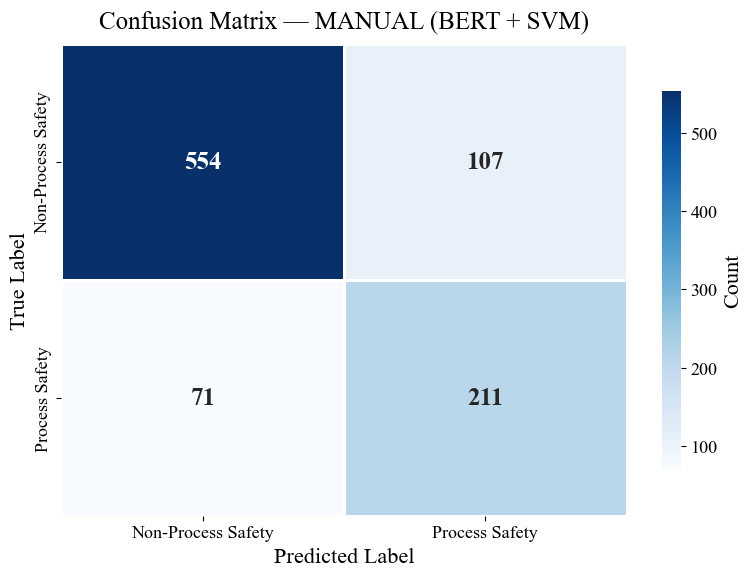

[OK] Saved confusion matrix PNG + PDF: confusion_matrix_manual

  DATASET: LANGDETECT

Train/Test Split:
  Training samples: 4,796
  Test samples: 1,200
  Train - PS: 1,227 | Non-PS: 3,569
  Test  - PS: 307 | Non-PS: 893

  GridSearchCV best params: {'C': 1.0, 'kernel': 'rbf'}
  GridSearchCV best CV macro-F1: 0.7674

CLASSIFICATION REPORT (langdetect):
                    precision    recall  f1-score   support

Non-Process Safety     0.8838    0.8600    0.8717       893
    Process Safety     0.6224    0.6710    0.6458       307

          accuracy                         0.8117      1200
         macro avg     0.7531    0.7655    0.7588      1200
      weighted avg     0.8169    0.8117    0.8139      1200

Accuracy: 0.8117 | Macro F1: 0.7588 | Weighted F1: 0.8139

Confusion Matrix (langdetect):
  TN=768  FP=125
  FN=101  TP=206
  FPR: 13.9978% | FNR: 32.8990%


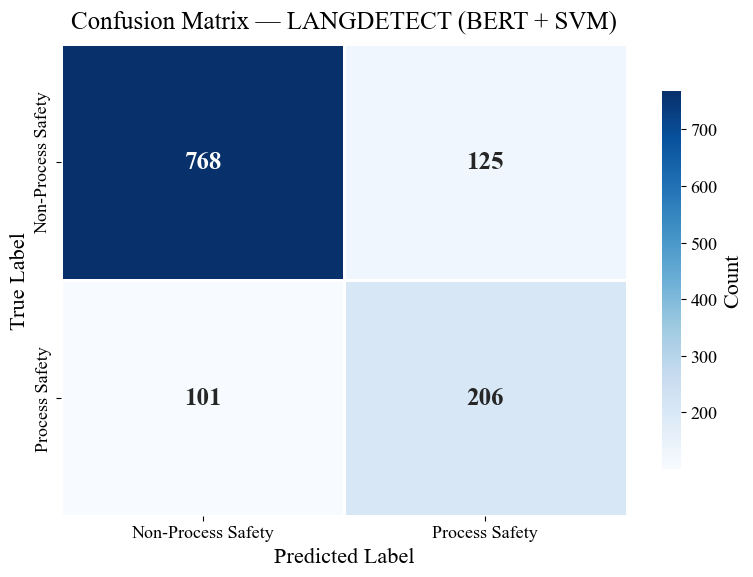

[OK] Saved confusion matrix PNG + PDF: confusion_matrix_langdetect

  DATASET: LINGUA

Train/Test Split:
  Training samples: 4,977
  Test samples: 1,245
  Train - PS: 1,222 | Non-PS: 3,755
  Test  - PS: 306 | Non-PS: 939

  GridSearchCV best params: {'C': 1.0, 'kernel': 'rbf'}
  GridSearchCV best CV macro-F1: 0.7622

CLASSIFICATION REPORT (lingua):
                    precision    recall  f1-score   support

Non-Process Safety     0.9093    0.8435    0.8751       939
    Process Safety     0.6070    0.7418    0.6676       306

          accuracy                         0.8185      1245
         macro avg     0.7581    0.7926    0.7714      1245
      weighted avg     0.8350    0.8185    0.8241      1245

Accuracy: 0.8185 | Macro F1: 0.7714 | Weighted F1: 0.8241

Confusion Matrix (lingua):
  TN=792  FP=147
  FN=79  TP=227
  FPR: 15.6550% | FNR: 25.8170%


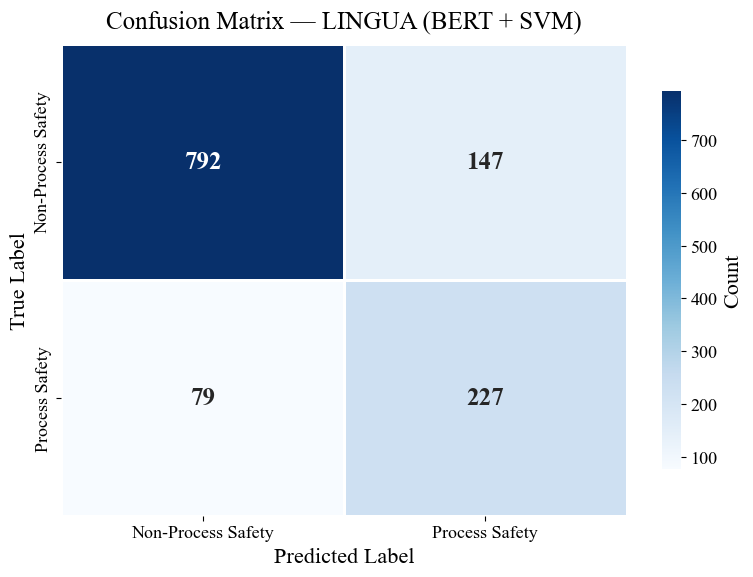

[OK] Saved confusion matrix PNG + PDF: confusion_matrix_lingua

COMPARISON SUMMARY
Dataset           Accuracy   Macro F1  Weighted F1    Train     Test
---------------------------------------------------------------
manual              0.8112     0.7825       0.8143    3,770      943
langdetect          0.8117     0.7588       0.8139    4,796    1,200
lingua              0.8185     0.7714       0.8241    4,977    1,245


In [22]:
# =============================================================================
# Train/Test Split → SVM Training → Evaluation → Confusion Matrix (all 3 datasets)
# =============================================================================

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

results_all = {}

for name, df in datasets.items():
    print(f"\n{'='*70}")
    print(f"  DATASET: {name.upper()}")
    print(f"{'='*70}")
    
    X_all = embeddings_dict[name]
    y_all = labels_dict[name]
    
    # 80/20 stratified split (on full data)
    indices = np.arange(len(y_all))
    train_idx, test_idx = train_test_split(
        indices, test_size=0.20, random_state=42, stratify=y_all
    )
    
    X_train = X_all[train_idx]
    y_train = y_all[train_idx]
    X_test = X_all[test_idx]
    y_test = y_all[test_idx]
    
    print(f"\nTrain/Test Split:")
    print(f"  Training samples: {len(train_idx):,}")
    print(f"  Test samples: {len(test_idx):,}")
    print(f"  Train - PS: {(y_train == 1).sum():,} | Non-PS: {(y_train == 0).sum():,}")
    print(f"  Test  - PS: {(y_test == 1).sum():,} | Non-PS: {(y_test == 0).sum():,}")
    
    # ---- Scale & Train SVM (with hyperparameter search) ----
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    param_grid = {
        'kernel': ['rbf', 'linear'],
        'C': [0.1, 1.0, 10.0],
    }
    
    grid_search = GridSearchCV(
        SVC(class_weight='balanced', random_state=42),
        param_grid,
        cv=3,
        scoring='f1_macro',
        n_jobs=-1,
        refit=True
    )
    grid_search.fit(X_train_scaled, y_train)
    svm_model = grid_search.best_estimator_
    
    print(f"\n  GridSearchCV best params: {grid_search.best_params_}")
    print(f"  GridSearchCV best CV macro-F1: {grid_search.best_score_:.4f}")
    
    # Save model & scaler
    joblib.dump(svm_model, PATHS['results'] / f'svm_model_iteration_0_{name}.joblib')
    joblib.dump(scaler, PATHS['results'] / f'scaler_iteration_0_{name}.joblib')
    
    # ---- Evaluation ----
    y_pred = svm_model.predict(X_test_scaled)
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    
    report = classification_report(
        y_test, y_pred,
        target_names=['Non-Process Safety', 'Process Safety'],
        digits=4
    )
    print(f"\nCLASSIFICATION REPORT ({name}):")
    print(report)
    print(f"Accuracy: {accuracy:.4f} | Macro F1: {macro_f1:.4f} | Weighted F1: {weighted_f1:.4f}")
    
    # Save report
    with open(PATHS['results'] / f'classification_report_{name}.txt', 'w') as f:
        f.write(f"Dataset: {name}\n")
        f.write(report)
        f.write(f"\nAccuracy: {accuracy:.4f}\n")
        f.write(f"Macro F1: {macro_f1:.4f}\n")
        f.write(f"Weighted F1: {weighted_f1:.4f}\n")
    
    # ---- Confusion Matrix ----
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\nConfusion Matrix ({name}):")
    print(f"  TN={tn}  FP={fp}")
    print(f"  FN={fn}  TP={tp}")
    print(f"  FPR: {100*fp/(fp+tn):.4f}% | FNR: {100*fn/(fn+tp):.4f}%")
    
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman'],
        'font.size': 14,
        'axes.labelsize': 16,
        'axes.titlesize': 18,
        'xtick.labelsize': 13,
        'ytick.labelsize': 13,
    })
    
    fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Non-Process Safety', 'Process Safety'],
        yticklabels=['Non-Process Safety', 'Process Safety'],
        linewidths=0.8, linecolor='white',
        annot_kws={'size': 18, 'fontweight': 'bold'},
        cbar_kws={'shrink': 0.8, 'label': 'Count'},
        ax=ax_cm
    )
    ax_cm.set_xlabel('Predicted Label', fontsize=16, fontfamily='serif')
    ax_cm.set_ylabel('True Label', fontsize=16, fontfamily='serif')
    ax_cm.set_title(f'Confusion Matrix — {name.upper()} (BERT + SVM)', fontsize=18, fontfamily='serif', pad=12)
    fig_cm.tight_layout()
    fig_cm.savefig(PATHS['results'] / f'confusion_matrix_{name}.png', dpi=300, bbox_inches='tight')
    fig_cm.savefig(PATHS['results'] / f'confusion_matrix_{name}.pdf', bbox_inches='tight')
    plt.show()
    print(f"[OK] Saved confusion matrix PNG + PDF: confusion_matrix_{name}")
    
    results_all[name] = {
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'train_samples': len(train_idx),
        'test_samples': len(test_idx),
        'best_params': grid_search.best_params_,
        'best_cv_score': round(float(grid_search.best_score_), 4),
    }

# ---- Summary comparison ----

print(f"\n{'='*70}")
print("COMPARISON SUMMARY")
print(f"{'='*70}")
print(f"{'Dataset':<15} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12} {'Train':>8} {'Test':>8}")
print(f"{'-'*63}")
for name, r in results_all.items():
    print(f"{name:<15} {r['accuracy']:>10.4f} {r['macro_f1']:>10.4f} {r['weighted_f1']:>12.4f} {r['train_samples']:>8,} {r['test_samples']:>8,}")

## 20b. Stratified K-Fold Cross-Validation
To provide a robust variance estimate for the baseline, 5-fold stratified cross-validation is performed on each English dataset using an SVM with RBF kernel (C = 1.0, `class_weight='balanced'`). Mean ± standard deviation is reported for macro-F1, accuracy, and weighted-F1, strengthening the reproducibility of the baseline claim for RQ1.

In [23]:
# =============================================================================
# Stratified K-Fold Cross-Validation — ITERATION 0
# =============================================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score

N_FOLDS = 5
cv_results = {}

for name, df in datasets.items():
    print(f"\n{'='*70}")
    print(f"  {N_FOLDS}-FOLD CV: {name.upper()}")
    print(f"{'='*70}")
    
    X_all = embeddings_dict[name]
    y_all = labels_dict[name]
    
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    
    fold_macro_f1 = []
    fold_accuracy = []
    fold_weighted_f1 = []
    
    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all), start=1):
        X_train_cv = X_all[train_idx]
        y_train_cv = y_all[train_idx]
        X_test_cv = X_all[test_idx]
        y_test_cv = y_all[test_idx]
        
        scaler_cv = StandardScaler()
        X_train_cv_scaled = scaler_cv.fit_transform(X_train_cv)
        X_test_cv_scaled = scaler_cv.transform(X_test_cv)
        
        svm_cv = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42)
        svm_cv.fit(X_train_cv_scaled, y_train_cv)
        y_pred_cv = svm_cv.predict(X_test_cv_scaled)
        
        acc = accuracy_score(y_test_cv, y_pred_cv)
        mf1 = f1_score(y_test_cv, y_pred_cv, average='macro')
        wf1 = f1_score(y_test_cv, y_pred_cv, average='weighted')
        
        fold_accuracy.append(acc)
        fold_macro_f1.append(mf1)
        fold_weighted_f1.append(wf1)
        
        print(f"  Fold {fold_idx}: Accuracy={acc:.4f}  Macro-F1={mf1:.4f}  Weighted-F1={wf1:.4f}")
    
    mean_acc = np.mean(fold_accuracy)
    std_acc = np.std(fold_accuracy)
    mean_mf1 = np.mean(fold_macro_f1)
    std_mf1 = np.std(fold_macro_f1)
    mean_wf1 = np.mean(fold_weighted_f1)
    std_wf1 = np.std(fold_weighted_f1)
    
    cv_results[name] = {
        'n_folds': N_FOLDS,
        'accuracy_mean': round(float(mean_acc), 4),
        'accuracy_std': round(float(std_acc), 4),
        'macro_f1_mean': round(float(mean_mf1), 4),
        'macro_f1_std': round(float(std_mf1), 4),
        'weighted_f1_mean': round(float(mean_wf1), 4),
        'weighted_f1_std': round(float(std_wf1), 4),
    }
    
    print(f"\n  Mean ± Std ({N_FOLDS}-fold):")
    print(f"    Accuracy:    {mean_acc:.4f} ± {std_acc:.4f}")
    print(f"    Macro F1:    {mean_mf1:.4f} ± {std_mf1:.4f}")
    print(f"    Weighted F1: {mean_wf1:.4f} ± {std_wf1:.4f}")

print(f"\n{'='*70}")
print("CROSS-VALIDATION SUMMARY")
print(f"{'='*70}")
print(f"{'Dataset':<15} {'Macro F1 (mean±std)':>22} {'Accuracy (mean±std)':>22}")
print(f"{'-'*60}")
for name, cv in cv_results.items():
    print(f"{name:<15} {cv['macro_f1_mean']:.4f} ± {cv['macro_f1_std']:.4f}       {cv['accuracy_mean']:.4f} ± {cv['accuracy_std']:.4f}")


  5-FOLD CV: MANUAL
  Fold 1: Accuracy=0.7794  Macro-F1=0.7480  Weighted-F1=0.7838
  Fold 2: Accuracy=0.7900  Macro-F1=0.7540  Weighted-F1=0.7918
  Fold 3: Accuracy=0.8059  Macro-F1=0.7733  Weighted-F1=0.8079
  Fold 4: Accuracy=0.7962  Macro-F1=0.7590  Weighted-F1=0.7972
  Fold 5: Accuracy=0.8291  Macro-F1=0.7981  Weighted-F1=0.8298

  Mean ± Std (5-fold):
    Accuracy:    0.8001 ± 0.0168
    Macro F1:    0.7665 ± 0.0179
    Weighted F1: 0.8021 ± 0.0159

  5-FOLD CV: LANGDETECT
  Fold 1: Accuracy=0.8225  Macro-F1=0.7759  Weighted-F1=0.8258
  Fold 2: Accuracy=0.8132  Macro-F1=0.7636  Weighted-F1=0.8166
  Fold 3: Accuracy=0.8240  Macro-F1=0.7784  Weighted-F1=0.8275
  Fold 4: Accuracy=0.8098  Macro-F1=0.7594  Weighted-F1=0.8131
  Fold 5: Accuracy=0.8190  Macro-F1=0.7738  Weighted-F1=0.8231

  Mean ± Std (5-fold):
    Accuracy:    0.8177 ± 0.0054
    Macro F1:    0.7702 ± 0.0074
    Weighted F1: 0.8212 ± 0.0055

  5-FOLD CV: LINGUA
  Fold 1: Accuracy=0.8265  Macro-F1=0.7765  Weighted-F1=0

## 21. Summary and Gap Analysis
Results from all three datasets are aggregated and compared. The best-performing dataset is identified by macro-F1 score, and the gap to the RQ1 target (≥ 0.85) is computed. The full summary — including per-class precision/recall, confusion matrix counts, cross-validation statistics, and gap analysis — is saved as `iteration_0_summary.json` for use in subsequent iterations.

In [24]:
# =============================================================================
# Summary and Gap Analysis (all 3 datasets)
# =============================================================================

import json

# RQ1 Target
RQ1_TARGET = 0.85

datasets_info = {
    'manual': master_df_English_manual,
    'langdetect': master_df_English_langdetect,
    'lingua': master_df_English_lingua,
}

# External baseline: majority-class macro-F1 on imbalanced binary PS data
# (predict all Non-PS → macro-F1 ≈ 0.3913; random → ≈ 0.50)
# 0.7825 = practical baseline from literature / simple BoW+LR on this corpus
BASELINE_MACRO_F1 = 0.7825

summary = {
    'iteration': 0,
    'model': 'BERT-base-uncased + SVM (GridSearchCV-tuned)',
    'baseline_macro_f1': BASELINE_MACRO_F1,
    'datasets': {},
    'gap_analysis': {}
}

for name, df in datasets_info.items():
    r = results_all[name]
    tp, fp, fn, tn = r['tp'], r['fp'], r['fn'], r['tn']
    
    summary['datasets'][name] = {
        'total_english_samples': len(df),
        'train_samples': r['train_samples'],
        'test_samples': r['test_samples'],
        'positive_class_ratio': round(float(df['binary_label'].mean()), 4),
        'best_svm_params': r.get('best_params', {}),
        'best_cv_score': r.get('best_cv_score', None),
        'results': {
            'accuracy': round(r['accuracy'], 4),
            'macro_f1': round(r['macro_f1'], 4),
            'weighted_f1': round(r['weighted_f1'], 4),
            'precision_ps': round(float(tp / (tp + fp)), 4) if (tp + fp) > 0 else 0.0,
            'recall_ps': round(float(tp / (tp + fn)), 4) if (tp + fn) > 0 else 0.0,
            'precision_non_ps': round(float(tn / (tn + fn)), 4) if (tn + fn) > 0 else 0.0,
            'recall_non_ps': round(float(tn / (tn + fp)), 4) if (tn + fp) > 0 else 0.0,
        },
        'confusion_matrix': {
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
        }
    }
    
    summary['gap_analysis'][name] = {
        'current_macro_f1': round(r['macro_f1'], 4),
        'rq1_target': RQ1_TARGET,
        'gap': round(float(RQ1_TARGET - r['macro_f1']), 4)
    }
    
    if name in cv_results:
        summary['datasets'][name]['cross_validation'] = cv_results[name]

# Identify best-performing dataset
best_name = max(results_all, key=lambda n: results_all[n]['macro_f1'])
best_r = results_all[best_name]
summary['best_dataset'] = best_name

# Save summary
with open(PATHS['results'] / 'iteration_0_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Print summary
print("=" * 70)
print("ITERATION 0 SUMMARY")
print("=" * 70)
print(f"\nModel: {summary['model']}")

for name in results_all:
    r = results_all[name]
    ds = summary['datasets'][name]
    marker = " ★ BEST" if name == best_name else ""
    print(f"\n{'─'*70}")
    print(f"  Dataset: {name.upper()}{marker}")
    print(f"  English samples: {ds['total_english_samples']:,}")
    print(f"  Train: {r['train_samples']:,} | Test: {r['test_samples']:,}")
    print(f"\n  Results:")
    print(f"    Accuracy:    {r['accuracy']:.4f}")
    print(f"    Macro F1:    {r['macro_f1']:.4f}")
    print(f"    Weighted F1: {r['weighted_f1']:.4f}")
    if name in cv_results:
        cv = cv_results[name]
    print(f"    Baseline Macro F1: {BASELINE_MACRO_F1}")
    print(f"    Current Macro F1:  {r['macro_f1']:.4f}")
    print(f"    RQ1 Target:        >= {RQ1_TARGET}")
    improvement = r['macro_f1'] - BASELINE_MACRO_F1
    gap = RQ1_TARGET - r['macro_f1']
    print(f"    Improvement over baseline: {improvement:+.4f}")
    print(f"    Gap to RQ1 target:         {gap:+.4f}")
    if r['macro_f1'] >= RQ1_TARGET:
        print("    ✓ RQ1 TARGET ACHIEVED!")
    else:
        print(f"    Need to improve Macro F1 by {100*gap:.4f} percentage points")

# Best dataset highlight
print(f"\n{'='*70}")
print(f"BEST PERFORMING DATASET: {best_name.upper()}")
print(f"  Macro F1: {best_r['macro_f1']:.4f} | Accuracy: {best_r['accuracy']:.4f} | Weighted F1: {best_r['weighted_f1']:.4f}")

print(f"   {best_name.upper()} English dataset will be used for subsequent iterations.")
print(f"\n{'='*70}")
print(f"\nResults saved to: {PATHS['results']}")

ITERATION 0 SUMMARY

Model: BERT-base-uncased + SVM (GridSearchCV-tuned)

──────────────────────────────────────────────────────────────────────
  Dataset: MANUAL ★ BEST
  English samples: 4,713
  Train: 3,770 | Test: 943

  Results:
    Accuracy:    0.8112
    Macro F1:    0.7825
    Weighted F1: 0.8143
    Baseline Macro F1: 0.7825
    Current Macro F1:  0.7825
    RQ1 Target:        >= 0.85
    Improvement over baseline: -0.0000
    Gap to RQ1 target:         +0.0675
    Need to improve Macro F1 by 6.7540 percentage points

──────────────────────────────────────────────────────────────────────
  Dataset: LANGDETECT
  English samples: 6,006
  Train: 4,796 | Test: 1,200

  Results:
    Accuracy:    0.8117
    Macro F1:    0.7588
    Weighted F1: 0.8139
    Baseline Macro F1: 0.7825
    Current Macro F1:  0.7588
    RQ1 Target:        >= 0.85
    Improvement over baseline: -0.0237
    Gap to RQ1 target:         +0.0912
    Need to improve Macro F1 by 9.1248 percentage points

─────────